# Paper 1 — Data Pull: NASA POWER Meteorological Context + Road-Centerline Distance

This notebook pulls the two remaining data items flagged in Paper 1:

1. **Section 2.8 / Table 5** — hourly meteorological context (wind speed, wind direction, temperature, precipitation) at each field site's own coordinates, using **NASA POWER** (a reanalysis grid, not a distant physical station — this replaces the earlier Don Mueang/Meteostat plan, which was ~65 km away and outside the local airshed).
2. **Section 2.9 / 3.6 / Table 6** — an actual road-centerline GIS layer for Mittraphap Road (Highway 2), pulled from OpenStreetMap, to replace the interpolated waypoint approximation.

**Before running:** fill in the `sites` list in the first code cell with your 32 sites' exact coordinates (or point it at a CSV you already have).

In [1]:
!pip -q install geopandas shapely requests pandas > /dev/null
print("Packages ready.")

Packages ready.


## Part A — NASA POWER hourly meteorological data

In [3]:
import re
import time
import requests
import pandas as pd

# ---- Reads your field log directly and resolves each Google Maps short link to lat/lon ----
# 1) Upload "บันทึกการตรวจวัดปริมาณฝุ่น.xlsx" into this Colab session first
#    (folder icon on the left > upload), then set the filename below if it differs.
XLSX_PATH = "บันทึกการตรวจวัดปริมาณฝุ่น.xlsx"

raw = pd.read_excel(XLSX_PATH)
raw = raw.rename(columns={raw.columns[0]: "site", raw.columns[1]: "maps_url", raw.columns[2]: "address"})
raw = raw.dropna(subset=["site", "maps_url"]).reset_index(drop=True)
print(f"Found {len(raw)} sites with a Google Maps link in the log.")

def resolve_latlon(short_url, max_retries=3):
    """Follow a goo.gl/maps redirect to the full Google Maps URL and extract lat/lon.
    Prefers the precise pin marker (!3d..!4d..) over the map-center coordinate (@lat,lon,zoom)."""
    for attempt in range(max_retries):
        try:
            r = requests.get(short_url, allow_redirects=True, timeout=20,
                              headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"})
            final_url = r.url
            m = re.search(r"!3d(-?\d+\.\d+)!4d(-?\d+\.\d+)", final_url)
            if m:
                return float(m.group(1)), float(m.group(2))
            m = re.search(r"@(-?\d+\.\d+),(-?\d+\.\d+)", final_url)
            if m:
                return float(m.group(1)), float(m.group(2))
            m = re.search(r"[?&]q=(-?\d+\.\d+),(-?\d+\.\d+)", final_url)
            if m:
                return float(m.group(1)), float(m.group(2))
            return None, None
        except Exception as e:
            if attempt == max_retries - 1:
                print(f"  could not resolve {short_url}: {e}")
                return None, None
            time.sleep(2)

lats, lons = [], []
for _, row in raw.iterrows():
    lat, lon = resolve_latlon(row["maps_url"])
    lats.append(lat)
    lons.append(lon)
    status = "OK" if lat is not None else "FAILED"
    print(f"{status}: {row['site']}  ->  {lat}, {lon}")
    time.sleep(0.5)

raw["lat"] = lats
raw["lon"] = lons

unresolved = raw[raw["lat"].isna()]
if len(unresolved) > 0:
    print(f"\n{len(unresolved)} site(s) could not be resolved automatically — check these manually on Google Maps:")
    print(unresolved[["site", "maps_url", "address"]].to_string(index=False))

raw[["site", "lat", "lon", "address"]].to_csv("paper1_32_sites_resolved.csv", index=False)
print(f"\nSaved paper1_32_sites_resolved.csv with {raw['lat'].notna().sum()} of {len(raw)} sites resolved.")

sites = raw[["site", "lat", "lon"]].to_dict("records")
raw[["site", "lat", "lon", "address"]].head(10)

Found 32 sites with a Google Maps link in the log.
OK: จุดตรวจวัดอากาศ-1  ->  15.1329699, 100.6037821
OK: จุดตรวจวัดอากาศ-2  ->  15.1323173, 100.860427
OK: จุดตรวจวัดอากาศ-3  ->  15.1313906, 101.1148911
OK: จุดตรวจวัดอากาศ-4  ->  15.1301891, 101.3710697
OK: จุดตรวจวัดอากาศ-5  ->  15.1286122, 101.6271326
OK: จุดตรวจวัดอากาศ-6  ->  14.884332, 100.6052271
OK: จุดตรวจวัดอากาศ-7  ->  14.8841998, 100.8607278
OK: จุดตรวจวัดอากาศ-8  ->  14.8838629, 101.1151294
OK: จุดตรวจวัดอากาศ-9  ->  14.8826264, 101.3709489
OK: จุดตรวจวัดอากาศ-10  ->  14.8824661, 101.6271879
OK: จุดตรวจวัดอากาศ-11  ->  14.6359424, 100.6066765
OK: จุดตรวจวัดอากาศ-12  ->  14.636086, 100.8610166
OK: จุดตรวจวัดอากาศ-13  ->  14.6360004, 101.1153643
OK: จุดตรวจวัดอากาศ-14  ->  14.6352958, 101.3709736
OK: จุดตรวจวัดอากาศ-15  ->  14.6347281, 101.6271853
OK: จุดตรวจวัดอากาศ-16  ->  14.3825713, 100.6081436
OK: จุดตรวจวัดอากาศ-17  ->  14.3844954, 100.8613155
OK: จุดตรวจวัดอากาศ-18  ->  14.3860999, 101.1155996
OK: จุดตรวจวัดอากาศ-19  -

,site,lat,lon,address
0,จุดตรวจวัดอากาศ-1,15.132970,100.603782,ตำบล ดอนดึง อำเภอ บ้านหมี่ ลพบุรี
1,จุดตรวจวัดอากาศ-2,15.132317,100.860427,ตำบล ดงมะรุม อำเภอ โคกสำโรง ลพบุรี
2,จุดตรวจวัดอากาศ-3,15.131391,101.114891,ตำบล ท่าดินดำ อำเภอชัยบาดาล ลพบุรี
3,จุดตรวจวัดอากาศ-4,15.130189,101.371070,ตำบล เขาน้อย อำเภอ ลำสนธิ ลพบุรี
4,จุดตรวจวัดอากาศ-5,15.128612,101.627133,ตำบล หินดาด อำเภอด่านขุนทด นครราชสีมา
5,จุดตรวจวัดอากาศ-6,14.884332,100.605227,ตำบล ท่าแค อำเภอเมืองลพบุรี ลพบุรี
6,จุดตรวจวัดอากาศ-7,14.884200,100.860728,ตำบล โคกตูม อำเภอเมืองลพบุรี ลพบุรี
7,จุดตรวจวัดอากาศ-8,14.883863,101.115129,ตำบล วังม่วง อำเภอ วังม่วง สระบุรี
8,จุดตรวจวัดอากาศ-9,14.882626,101.370949,ตำบล ลำพญากลาง อำเภอมวกเหล็ก สระบุรี
9,จุดตรวจวัดอากาศ-10,14.882466,101.627188,ตำบล ลาดบัวขาว อำเภอสีคิ้ว นครราชสีมา


In [4]:
# ---- Now fetch NASA POWER hourly meteorological data for each resolved site ----
PARAMS = "WS10M,WD10M,T2M,PRECTOTCORR"   # wind speed, wind direction, temperature, precipitation
START, END = "20230605", "20230629"       # campaign window (5-29 June 2023)

def fetch_power_hourly(lat, lon, start=START, end=END, params=PARAMS):
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
    r = requests.get(url, params={
        "parameters": params,
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON",
    }, timeout=60)
    r.raise_for_status()
    return r.json()

all_rows = []
for s in sites:
    if s["lat"] is None or s["lon"] is None or pd.isna(s["lat"]) or pd.isna(s["lon"]):
        print(f"Skipping {s['site']} — coordinates could not be resolved, check paper1_32_sites_resolved.csv")
        continue
    try:
        data = fetch_power_hourly(s["lat"], s["lon"])
        param_data = data["properties"]["parameter"]
        first_param = PARAMS.split(",")[0]
        timestamps = list(param_data[first_param].keys())
        for ts in timestamps:
            row = {"site": s["site"], "lat": s["lat"], "lon": s["lon"], "datetime": ts}
            for p in PARAMS.split(","):
                row[p] = param_data[p][ts]
            all_rows.append(row)
        print(f"OK: {s['site']} ({len(timestamps)} hourly rows)")
    except Exception as e:
        print(f"FAILED: {s['site']}: {e}")
    time.sleep(1)  # be polite to the API

df_met = pd.DataFrame(all_rows)
df_met.to_csv("paper1_nasa_power_hourly.csv", index=False)
print(f"\nSaved {len(df_met)} rows to paper1_nasa_power_hourly.csv")

if df_met.empty or "datetime" not in df_met.columns:
    raise ValueError(
        "df_met is empty — none of the resolved sites returned data.\n"
        "Check paper1_32_sites_resolved.csv for unresolved coordinates, or check "
        "your internet connection to power.larc.nasa.gov, then re-run this cell."
    )

df_met.head()

OK: จุดตรวจวัดอากาศ-1 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-2 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-3 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-4 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-5 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-6 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-7 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-8 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-9 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-10 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-11 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-12 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-13 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-14 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-15 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-16 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-17 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-18 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-19 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-20 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-21 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-22 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-23 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-24 (600 hourly rows)
OK: จุดตรวจวัดอากาศ-25 (6

,site,lat,lon,datetime,WS10M,WD10M,T2M,PRECTOTCORR
0,จุดตรวจวัดอากาศ-1,15.13297,100.603782,2023060500,3.41,210.1,27.75,4.83
1,จุดตรวจวัดอากาศ-1,15.13297,100.603782,2023060501,3.70,205.1,27.34,4.71
2,จุดตรวจวัดอากาศ-1,15.13297,100.603782,2023060502,3.53,202.5,26.98,4.29
3,จุดตรวจวัดอากาศ-1,15.13297,100.603782,2023060503,2.69,204.2,26.72,3.75
4,จุดตรวจวัดอากาศ-1,15.13297,100.603782,2023060504,2.03,201.4,26.49,2.35


### Aggregate into the Table 5 shape

Table 5 in the manuscript needs a row per key campaign date (5-Jun, 7-Jun / Tab Kwang, and a summary for the 11-29 Jun range), with mean wind direction, mean wind speed, and precipitation. Adjust the `key_dates` list and the site used to represent "province-level" conditions as needed.

In [5]:
df_met["date"] = pd.to_datetime(df_met["datetime"], format="%Y%m%d%H").dt.date

# circular mean for wind direction (simple vector average)
import numpy as np
def circular_mean_deg(degrees):
    rad = np.deg2rad(degrees.dropna())
    if len(rad) == 0:
        return np.nan
    return (np.rad2deg(np.arctan2(np.sin(rad).mean(), np.cos(rad).mean())) + 360) % 360

daily = df_met.groupby(["site", "date"]).agg(
    mean_wind_dir=("WD10M", circular_mean_deg),
    mean_wind_speed=("WS10M", "mean"),
    precipitation=("PRECTOTCORR", "sum"),
).reset_index()

daily.to_csv("paper1_table5_daily_summary.csv", index=False)
daily.head(20)

,site,date,mean_wind_dir,mean_wind_speed,precipitation
0,จุดตรวจวัดอากาศ-1,2023-06-05,219.293715,3.454583,76.45
1,จุดตรวจวัดอากาศ-1,2023-06-06,198.826991,3.319583,103.00
2,จุดตรวจวัดอากาศ-1,2023-06-07,195.595690,4.214167,272.70
3,จุดตรวจวัดอากาศ-1,2023-06-08,205.351295,4.282500,52.00
4,จุดตรวจวัดอากาศ-1,2023-06-09,206.693899,3.976667,120.78
5,จุดตรวจวัดอากาศ-1,2023-06-10,208.698001,4.248333,33.07
6,จุดตรวจวัดอากาศ-1,2023-06-11,212.779181,4.029583,80.19
7,จุดตรวจวัดอากาศ-1,2023-06-12,216.973625,4.662083,10.79
8,จุดตรวจวัดอากาศ-1,2023-06-13,212.157717,5.212500,185.55
9,จุดตรวจวัดอากาศ-1,2023-06-14,206.787108,5.177500,89.83


## Part B — Road-centerline distance (Mittraphap Road / Highway 2, via OpenStreetMap Overpass API)

In [6]:
# Overpass API's free public mirrors are currently unreliable (406/500 errors
# across all four tried) — this switches to a more robust approach: download
# Thailand's OSM extract as a file from Geofabrik (a long-established, stable
# OSM mirror used widely in GIS work — a plain file download, not a rate-limited
# query API), then filter the road network locally with pyrosm.

!pip -q install pyrosm geopandas shapely > /dev/null

import os
import requests
import geopandas as gpd

geofabrik_url = "https://download.geofabrik.de/asia/thailand-latest.osm.pbf"
pbf_path = "thailand-latest.osm.pbf"

if not os.path.exists(pbf_path):
    print("Downloading Thailand OSM extract from Geofabrik (roughly 150-250 MB, may take a few minutes)...")
    with requests.get(geofabrik_url, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        downloaded = 0
        with open(pbf_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
                downloaded += len(chunk)
                if total:
                    print(f"\r  {downloaded / 1e6:.0f} / {total / 1e6:.0f} MB", end="")
    print("\nDownload complete.")
else:
    print("Thailand OSM extract already downloaded.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
  327 / 327 MB
Download complete.


Loaded 125121 road segments in the bounding box.
Matched 60 segments named Mittraphap Road.
Saved mittraphap_road_centerline.geojson


<Axes: >

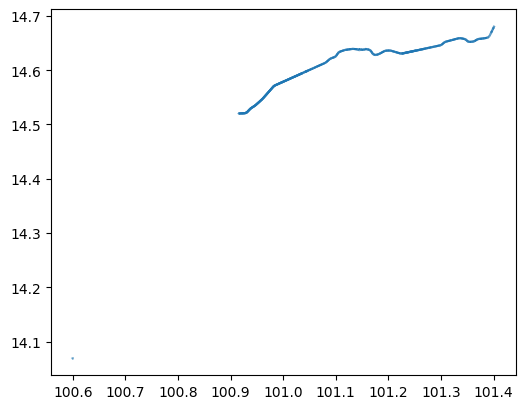

In [7]:
import pyrosm

# Bounding box roughly covering the seven-province sampling extent: [minlon, minlat, maxlon, maxlat]
bbox = [100.4, 13.9, 101.4, 15.2]

osm = pyrosm.OSM(pbf_path, bounding_box=bbox)
roads = osm.get_network(network_type="driving")
print(f"Loaded {len(roads)} road segments in the bounding box.")

# Filter to Mittraphap Road (Highway 2) by name — Thai and English spellings
mittraphap = roads[roads["name"].astype(str).str.contains("มิตรภาพ|Mittraphap", case=False, na=False)]
print(f"Matched {len(mittraphap)} segments named Mittraphap Road.")

if len(mittraphap) == 0:
    # Fallback: try the ref tag (Highway 2) if the name tag isn't populated consistently here
    if "ref" in roads.columns:
        mittraphap = roads[roads["ref"].astype(str).str.contains(r"^2$|;2;|;2$|^2;", na=False, regex=True)]
        print(f"Fallback ref='2' match: {len(mittraphap)} segments.")

road_gdf = mittraphap[["name", "ref", "geometry"]].reset_index(drop=True)
road_gdf = road_gdf.set_crs("EPSG:4326") if road_gdf.crs is None else road_gdf.to_crs("EPSG:4326")
road_gdf.to_file("mittraphap_road_centerline.geojson", driver="GeoJSON")
print("Saved mittraphap_road_centerline.geojson")
road_gdf.plot(figsize=(6, 6))

In [9]:
# ---- Compute distance from each site to the road centerline ----
# Uses the coordinates resolved from your Google Maps links in Part A
import geopandas as gpd
from shapely.ops import unary_union
import pandas as pd

sites_df = pd.read_csv("paper1_32_sites_resolved.csv")
sites_df = sites_df.dropna(subset=["lat", "lon"])  # drop any sites that failed to resolve

sites_gdf = gpd.GeoDataFrame(
    sites_df,
    geometry=gpd.points_from_xy(sites_df["lon"], sites_df["lat"]),
    crs="EPSG:4326",
)

# Project to UTM zone 47N (covers central Thailand) for metric distance
sites_gdf_m = sites_gdf.to_crs("EPSG:32647")
road_gdf_m = road_gdf.to_crs("EPSG:32647")
road_union_m = unary_union(road_gdf_m.geometry)

sites_gdf_m["dist_to_road_km"] = sites_gdf_m.geometry.apply(lambda p: p.distance(road_union_m) / 1000)

out = sites_gdf_m.drop(columns="geometry")
out.to_csv("paper1_road_distance_centerline.csv", index=False)
print("Saved paper1_road_distance_centerline.csv — use this to replace the Section 3.6 / Table 6 road-distance column.")
out[["site", "dist_to_road_km"]].sort_values("dist_to_road_km").head(10)

Saved paper1_road_distance_centerline.csv — use this to replace the Section 3.6 / Table 6 road-distance column.


,site,dist_to_road_km
12,จุดตรวจวัดอากาศ-13,0.057184
25,จุดตรวจวัดอากาศ-survey-0,0.240847
26,จุดตรวจวัดอากาศ-survey-1,1.736181
13,จุดตรวจวัดอากาศ-14,2.154142
27,จุดตรวจวัดอากาศ-survey-2,4.448692
20,จุดตรวจวัดอากาศ-21,7.575192
28,จุดตรวจวัดอากาศ-survey-3,10.719111
11,จุดตรวจวัดอากาศ-12,13.966426
16,จุดตรวจวัดอากาศ-17,16.028136
29,จุดตรวจวัดอากาศ-survey-4,18.333072


---
**Next steps once you have both CSVs:**
- Drop `paper1_table5_daily_summary.csv` values into Table 5 in the manuscript.
- Re-compute the road-distance correlations in Section 3.6 / Table 6 using `dist_to_road_km` from `paper1_road_distance_centerline.csv` in place of the old approximated-route distances, and re-run the Gi\* proximity comparison (Table 6).